# ConvNeXt satellite

In [1]:
# # 1. SETUP AND IMPORTS

In [2]:
!pip install rasterio torchinfo "wandb[media]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 46.3 MB/s eta 0:00:00


In [3]:
# Standard Library Imports
import os
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass, field, asdict

# Data Handling and Visualization
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import rasterio
from rasterio.errors import NotGeoreferencedWarning

# PyTorch and Torchvision
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Augmentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

# TorchMetrics for robust evaluation
import torchmetrics
from torchmetrics.classification import BinaryJaccardIndex

# Utilities
from tqdm.notebook import tqdm

from torchinfo import summary

# Experiment Tracking
import wandb

# Ignore non-critical rasterio warnings about georeferencing
warnings.filterwarnings("ignore", category=NotGeoreferencedWarning)

In [4]:
# --- W&B LOGIN ---
# This cell handles the login to Weights & Biases.
#
# INSTRUCTIONS:
# 1. Get your W&B API key from wandb.ai/authorize
# 2. In the Kaggle Editor, go to "Add-ons" -> "Secrets".
# 3. Create a new secret with the name "WANDB_API_KEY" and paste your key as the value.
# 4. Attach the secret to this notebook by toggling the switch.
#
# The wandb.login() command will automatically find and use this secret.
try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    api_key = user_secrets.get_secret("WANDB_API_KEY")
    wandb.login(key=api_key)
    print("W&B login successful from Kaggle Secrets.")
except ImportError:
    print("Proceeding with standard W&B login. Please enter your API key if prompted.")
    wandb.login()
except Exception as e:
    print(f"Fatal error: Could not log in to W&B. Please check your Kaggle Secret. Error: {e}")
    raise e

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: duncanb013 (duncanb013-polytechnic-university-of-the-philippines) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login successful from Kaggle Secrets.


# 2. CONFIGURATION

All experimental parameters are defined here. Modify the `config` object to iterate on different settings.

In [5]:
@dataclass
class Config:
    """
    Central configuration class for the training pipeline.
    """
    # --- Data Paths ---
    ORIGINAL_DATA_ROOT: Path = Path("/kaggle/input/quezon-city-informal-settlements/qc")
    AUGMENTED_DATA_ROOT: Path = Path("/kaggle/input/quezon-city-informal-settlements/qc-aug")
    SAT_SLIDEMIX_AUG_DATA_ROOT: Path = Path("/kaggle/input/quezon-city-informal-settlements/qc-sat-slidemix-aug")
    CHECKPOINT_DIR: Path = Path("/kaggle/working/")

    # --- Experiment Settings ---
    # Choose from: "satellite", "bc", "bh", "bc+sat", "all"
    MODALITY_TO_RUN: str = "satellite"
    
    # --- Data Splitting and Loading ---
    VAL_SPLIT: float = 0.25
    TEST_SPLIT: float = 0.25
    RANDOM_SEED: int = 42
    BATCH_SIZE: int = 64
    NUM_WORKERS: int = 2

    # --- Model Architecture ---
    ENCODER_CHANNEL_LIST: list[int] = field(default_factory=lambda: [80, 160, 320, 640])
    ENCODER_BLOCKS_PER_STAGE: list[int] = field(default_factory=lambda: [2, 2, 8, 2])
    DECODER_CONVNEXT_BLOCKS: list[int] = field(default_factory=lambda: [2, 2, 2, 2])
    FINAL_UPSAMPLING_CHANNELS: list[int] = field(default_factory=lambda: [80, 40, 20])
    ENCODER_DROP_PATH_RATE: float = 0.0
    ENCODER_LAYER_SCALE_INIT_VALUE: float = 1e-6

    # --- Training Parameters ---
    NUM_EPOCHS: int = 100
    LEARNING_RATE: float = 1e-4
    WEIGHT_DECAY: float = 5e-4
    DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
    
    # --- Augmentations & Normalization ---
    AUGMENTATION_PROB: float = 0.5
    # Dataset stats for all 5 channels (RGB, BC, BH)
    RGB_MEAN: list[float] = field(default_factory=lambda: [0.33969313, 0.35239491, 0.28135468])
    RGB_STD: list[float] = field(default_factory=lambda: [0.23594516, 0.20353660, 0.20314776])
    BC_MEAN: list[float] = field(default_factory=lambda: [0.0009436231339350343])
    BC_STD: list[float] = field(default_factory=lambda: [0.001719754422083497])
    BH_MEAN: list[float] = field(default_factory=lambda: [3.086625337600708])
    BH_STD: list[float] = field(default_factory=lambda: [5.610204696655273])

    # --- Evaluation ---
    METRIC_THRESHOLD: float = 0.6 # Threshold for monitoring metrics during training/validation

    # --- Dynamic Properties (set after initialization) ---
    INPUT_CHANNELS: int = 0
    CURRENT_MEAN: list[float] = field(default_factory=list)
    CURRENT_STD: list[float] = field(default_factory=list)

def setup_config() -> Config:
    """Initializes and dynamically updates the configuration."""
    config = Config()

    # --- DYNAMIC CONFIGURATION BASED ON MODALITY ---
    if config.MODALITY_TO_RUN == "satellite":
        config.INPUT_CHANNELS = 3
        config.CURRENT_MEAN = config.RGB_MEAN
        config.CURRENT_STD = config.RGB_STD
    elif config.MODALITY_TO_RUN == "bc":
        config.INPUT_CHANNELS = 1
        config.CURRENT_MEAN = config.BC_MEAN
        config.CURRENT_STD = config.BC_STD
    elif config.MODALITY_TO_RUN == "bh":
        config.INPUT_CHANNELS = 1
        config.CURRENT_MEAN = config.BH_MEAN
        config.CURRENT_STD = config.BH_STD
    elif config.MODALITY_TO_RUN == "bc+sat":
        config.INPUT_CHANNELS = 4
        config.CURRENT_MEAN = config.RGB_MEAN + config.BC_MEAN
        config.CURRENT_STD = config.RGB_STD + config.BC_STD
    elif config.MODALITY_TO_RUN == "all":
        config.INPUT_CHANNELS = 5
        config.CURRENT_MEAN = config.RGB_MEAN + config.BC_MEAN + config.BH_MEAN
        config.CURRENT_STD = config.RGB_STD + config.BC_STD + config.BH_STD
    else:
        raise ValueError(f"MODALITY_TO_RUN must be one of 'satellite', 'bc', 'bh', 'bc+sat', or 'all'.")
        
    print(f"Running experiment with MODALITY: {config.MODALITY_TO_RUN} ({config.INPUT_CHANNELS} channels)")
    return config

# --- Initialize and setup configuration ---
config = setup_config()

# --- Set seed for reproducibility ---
torch.manual_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)
random.seed(config.RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.RANDOM_SEED)

Running experiment with MODALITY: satellite (3 channels)


# 3. UTILITIES AND HELPER FUNCTIONS

In [6]:
# --- Generic Model Building Blocks ---

class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape,)

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x

def drop_path(x, drop_prob: float = 0., training: bool = False, scale_by_keep: bool = True):
    if drop_prob == 0. or not training:
        return x
    keep_prob = 1 - drop_prob
    shape = (x.shape[0],) + (1,) * (x.ndim - 1)
    random_tensor = x.new_empty(shape).bernoulli_(keep_prob)
    if keep_prob > 0.0 and scale_by_keep:
        random_tensor.div_(keep_prob)
    return x * random_tensor

class DropPath(nn.Module):
    def __init__(self, drop_prob=None, scale_by_keep=True):
        super(DropPath, self).__init__()
        self.drop_prob = drop_prob
        self.scale_by_keep = scale_by_keep

    def forward(self, x):
        return drop_path(x, self.drop_prob, self.training, self.scale_by_keep)


def analyze_mask_distribution(config: Config, id_splits: dict):
    """
    Analyzes and prints the pixel distribution (target vs. background)
    for the masks in each data split.
    """
    print("\n--- Analyzing Mask Pixel Distribution ---")

    # This helper function is self-contained to keep the analysis independent.
    def _find_mask_path(img_stem, config):
        possible_exts = ['.png', '.jpg', '.tif', '.jpeg']
        search_dirs = [
            config.ORIGINAL_DATA_ROOT / "mask-256",
            config.AUGMENTED_DATA_ROOT / "mask-aug-256",
            config.SAT_SLIDEMIX_AUG_DATA_ROOT / "mask-sat-slidemix-aug-256"
        ]
        for base_dir in search_dirs:
            for ext in possible_exts:
                file_path = base_dir / (img_stem + ext)
                if file_path.exists():
                    return file_path
        print(f"Warning: Mask for {img_stem} not found. Skipping.")
        return None

    for split_name, ids in id_splits.items():
        if not ids:
            continue
        
        total_pixels = 0
        target_pixels = 0
        
        # Use tqdm from the main script scope
        for img_id in tqdm(ids, desc=f"Analyzing {split_name} masks", leave=False):
            mask_path = _find_mask_path(img_id, config)
            if not mask_path:
                continue
            
            with Image.open(mask_path) as mask_img:
                mask_np = (np.array(mask_img.convert("L")) > 0)
                target_pixels += np.sum(mask_np)
                total_pixels += mask_np.size
            
        if total_pixels > 0:
            target_percent = (target_pixels / total_pixels) * 100
            bg_percent = 100 - target_percent
            print(f"Split: {split_name.upper():<5} | Tiles: {len(ids):<5} | Target: {target_percent:.2f}% | Background: {bg_percent:.2f}%")
    print("-----------------------------------------")

In [7]:
# OLD --- Metric Functions ---
# We now try to use the torchmetrics functions
def dice_coefficient(preds, targets, smooth=1e-6):
    preds_flat = preds.contiguous().view(preds.shape[0], -1)
    targets_flat = targets.contiguous().view(targets.shape[0], -1)
    intersection = (preds_flat * targets_flat).sum(dim=1)
    dice_score = (2. * intersection + smooth) / (preds_flat.sum(dim=1) + targets_flat.sum(dim=1) + smooth)
    return dice_score.mean()

def iou_score(preds, targets, smooth=1e-6):
    preds_flat = preds.contiguous().view(preds.shape[0], -1)
    targets_flat = targets.contiguous().view(targets.shape[0], -1)
    intersection = (preds_flat * targets_flat).sum(dim=1)
    total = (preds_flat + targets_flat).sum(dim=1)
    union = total - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou.mean()

# 4. DATA PIPELINE

Defines the custom `Dataset` class and the logic for creating `DataLoaders` with the correct train/val/test splits.

In [8]:
class SatelliteDataset(Dataset):
    """
    Custom dataset for loading multi-modal satellite imagery and masks.
    It handles loading from the original data directory.
    """
    def __init__(self, config: Config, image_ids: list[str], transform=None, aug_transform=None):
        self.original_data_root = config.ORIGINAL_DATA_ROOT
        self.image_ids = image_ids
        self.transform = transform
        self.aug_transform = aug_transform
        self.modality = config.MODALITY_TO_RUN
        self.possible_exts = ['.png', '.jpg', '.tif', '.jpeg']

        # Pre-build directory paths for faster access
        self.dirs = {
            'sat': self.original_data_root / "satellite-256",
            'mask': self.original_data_root / "mask-256",
            'bc': self.original_data_root / "bc-256",
            'bh': self.original_data_root / "bh-256",
        }

    def __len__(self):
        return len(self.image_ids)

    def _find_file(self, modality_key, file_stem):
        # Search original directory
        base_dir = self.dirs[modality_key]
        for ext in self.possible_exts:
            file_path = base_dir / (file_stem + ext)
            if file_path.exists():
                return file_path
        
        raise FileNotFoundError(f"Could not find file for ID '{file_stem}' in {modality_key} directory: {base_dir}")

    def __getitem__(self, idx):
        img_base_name = self.image_ids[idx]
            
        if self.modality == 'satellite':
            path = self._find_file('sat', img_base_name)
            image_to_process_HWC = np.array(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0
        elif self.modality == 'bc':
            path = self._find_file('bc', img_base_name)
            with rasterio.open(path) as src:
                image_to_process_HWC = np.expand_dims(src.read(1).astype(np.float32), axis=-1)
        elif self.modality == 'bh':
            path = self._find_file('bh', img_base_name)
            with rasterio.open(path) as src:
                image_to_process_HWC = np.expand_dims(src.read(1).astype(np.float32), axis=-1)
        elif self.modality == 'bc+sat':
            img_rgb = np.array(Image.open(self._find_file('sat', img_base_name)).convert("RGB"), dtype=np.float32) / 255.0
            with rasterio.open(self._find_file('bc', img_base_name)) as src:
                img_bc = np.expand_dims(src.read(1).astype(np.float32), axis=-1)
            image_to_process_HWC = np.concatenate((img_rgb, img_bc), axis=-1)
        elif self.modality == 'all':
            img_rgb = np.array(Image.open(self._find_file('sat', img_base_name)).convert("RGB"), dtype=np.float32) / 255.0
            with rasterio.open(self._find_file('bc', img_base_name)) as src:
                img_bc = np.expand_dims(src.read(1).astype(np.float32), axis=-1)
            with rasterio.open(self._find_file('bh', img_base_name)) as src:
                img_bh = np.expand_dims(src.read(1).astype(np.float32), axis=-1)
            image_to_process_HWC = np.concatenate((img_rgb, img_bc, img_bh), axis=-1)
        else:
            raise ValueError(f"Unknown modality: {self.modality}")

        mask_path = self._find_file('mask', img_base_name)
        mask_np_HW = (np.array(Image.open(mask_path).convert("L")) > 0).astype(np.float32)

        if self.aug_transform:
            augmented = self.aug_transform(image=image_to_process_HWC, mask=mask_np_HW)
            image_aug_HWC, mask_aug_HW = augmented['image'], augmented['mask']
        else:
            image_aug_HWC, mask_aug_HW = image_to_process_HWC, mask_np_HW

        if self.transform:
            transformed = self.transform(image=image_aug_HWC, mask=mask_aug_HW)
            image_CHW, mask_HW = transformed['image'], transformed['mask']
            mask_1HW = mask_HW.unsqueeze(0)
        else:
            image_CHW = torch.from_numpy(image_aug_HWC.transpose(2, 0, 1))
            mask_1HW = torch.from_numpy(mask_aug_HW).unsqueeze(0).float()

        return image_CHW, mask_1HW

# added online augmentation of SatSlideMix custom for albumentations like my other aug transforms
class SatSlideMixAlb(A.DualTransform):
    """
    Custom Albumentations transform to apply Sat-SlideMix, which is a
    circular shift along a randomly chosen dimension. This is applied to
    both the image and the mask.
    """
    def __init__(self, beta=(0.0, 1.0), p=0.5):
        super().__init__(p=p)
        self.beta = beta

    def get_params_dependent_on_data(self, params, data):
        # Get image shape from the data dictionary
        height, width = data['image'].shape[:2]
        dims = {0: height, 1: width}

        dim = self.py_random.choice([0, 1])
        shift_fraction = self.py_random.uniform(self.beta[0], self.beta[1])

        # Perform all calculations here
        size = dims[dim]
        shift = int(size * shift_fraction)

        return {"dim": dim, "shift": shift}

    def apply(self, img, dim=0, shift=0, **params):
        return np.roll(img, shift=shift, axis=dim)

    def apply_to_mask(self, mask, dim=0, shift=0, **params):
        return np.roll(mask, shift=shift, axis=dim)

    def get_transform_init_args_names(self):
        return ("beta",)


def get_transforms(config: Config, is_train=True):
    aug_transform = None
    if is_train:
        aug_transform = A.Compose([
            A.HorizontalFlip(p=config.AUGMENTATION_PROB),
            A.VerticalFlip(p=config.AUGMENTATION_PROB),
            A.RandomRotate90(p=config.AUGMENTATION_PROB),
            SatSlideMixAlb(p=config.AUGMENTATION_PROB)
        ])

    final_transform = A.Compose([
        A.Normalize(mean=config.CURRENT_MEAN, std=config.CURRENT_STD, max_pixel_value=1.0),
        ToTensorV2()
    ])
    return aug_transform, final_transform

def get_dataloaders(config: Config):
    original_satellite_dir = config.ORIGINAL_DATA_ROOT / "satellite-256"
    all_base_ids = sorted([f.stem for f in original_satellite_dir.iterdir() if f.is_file()])
    
    total_size = len(all_base_ids)
    val_size = int(config.VAL_SPLIT * total_size)
    test_size = int(config.TEST_SPLIT * total_size)
    
    generator = torch.Generator().manual_seed(config.RANDOM_SEED)
    indices = torch.randperm(total_size, generator=generator).tolist()
    
    train_ids = [all_base_ids[i] for i in indices[:-val_size-test_size]]
    val_ids = [all_base_ids[i] for i in indices[-val_size-test_size:-test_size]]
    test_ids = [all_base_ids[i] for i in indices[-test_size:]]

    total_samples = len(train_ids) + len(val_ids) + len(test_ids)
    train_pct = (len(train_ids) / total_samples) * 100 if total_samples > 0 else 0
    val_pct = (len(val_ids) / total_samples) * 100 if total_samples > 0 else 0
    test_pct = (len(test_ids) / total_samples) * 100 if total_samples > 0 else 0

    print("\n--- Dataset Splitting Logic ---")
    print(f"Splitting {total_size} original tiles:")
    print(f"- Train: {len(train_ids)} tiles ({train_pct:.1f}%)")
    print(f"- Val:   {len(val_ids)} tiles ({val_pct:.1f}%)")
    print(f"- Test:  {len(test_ids)} tiles ({test_pct:.1f}%)")
    print("-------------------------------------\n")

    train_aug, train_final = get_transforms(config, is_train=True)
    val_aug, val_final = get_transforms(config, is_train=False)

    dataloaders = {}
    if train_ids:
        train_dataset = SatelliteDataset(config, train_ids, train_final, train_aug)
        dataloaders['train'] = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS, pin_memory=True)
    if val_ids:
        val_dataset = SatelliteDataset(config, val_ids, val_final, val_aug)
        dataloaders['val'] = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)
    if test_ids:
        test_dataset = SatelliteDataset(config, test_ids, val_final, val_aug)
        dataloaders['test'] = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS, pin_memory=True)

    id_splits = {'train': train_ids, 'val': val_ids, 'test': test_ids}
    return dataloaders, id_splits

# 5. MODEL COMPONENTS

This section defines the reusable building blocks for all models, such as the ConvNeXt encoder and various decoder architectures.

In [9]:
class ConvNeXtBlock(nn.Module):
    def __init__(self, dim, drop_path_rate=0., layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm = LayerNorm(dim, eps=1e-6, data_format="channels_first")
        self.pwconv1 = nn.Conv2d(dim, 4 * dim, kernel_size=1)
        self.act = nn.GELU()
        self.pwconv2 = nn.Conv2d(4 * dim, dim, kernel_size=1)
        self.gamma = nn.Parameter(layer_scale_init_value * torch.ones((dim, 1, 1)), requires_grad=True) if layer_scale_init_value > 0 else None
        self.drop_path = DropPath(drop_path_rate) if drop_path_rate > 0. else nn.Identity()

    def forward(self, x):
        shortcut = x
        x = self.dwconv(x)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = shortcut + self.drop_path(x)
        return x

class ConvNeXtEncoder(nn.Module):
    """A standalone ConvNeXt encoder that returns features from each stage."""
    def __init__(self, config: Config, in_chans: int):
        super().__init__()
        self.dims = config.ENCODER_CHANNEL_LIST
        self.depths = config.ENCODER_BLOCKS_PER_STAGE
        
        total_blocks = sum(self.depths)
        dp_rates = [x.item() for x in torch.linspace(0, config.ENCODER_DROP_PATH_RATE, total_blocks)]
        
        self.stem = nn.Sequential(
            nn.Conv2d(in_chans, self.dims[0], kernel_size=4, stride=4),
            LayerNorm(self.dims[0], eps=1e-6, data_format="channels_first")
        )
        
        self.stages = nn.ModuleList()
        self.downsamplers = nn.ModuleList()
        
        cursor = 0
        for i in range(4):
            # Downsampler before each stage (except the first)
            if i > 0:
                downsampler = nn.Sequential(
                    LayerNorm(self.dims[i-1], eps=1e-6, data_format="channels_first"),
                    nn.Conv2d(self.dims[i-1], self.dims[i], kernel_size=2, stride=2),
                )
                self.downsamplers.append(downsampler)

            # Stage blocks
            stage_dp_rates = dp_rates[cursor : cursor + self.depths[i]]
            stage = nn.Sequential(*[
                ConvNeXtBlock(self.dims[i], stage_dp_rates[j], config.ENCODER_LAYER_SCALE_INIT_VALUE)
                for j in range(self.depths[i])
            ])
            self.stages.append(stage)
            cursor += self.depths[i]
            
        self.output_channels = self.dims

    def forward(self, x):
        features = {}
        x = self.stem(x)
        x = self.stages[0](x)
        features['s1'] = x
        
        x = self.downsamplers[0](x)
        x = self.stages[1](x)
        features['s2'] = x
        
        x = self.downsamplers[1](x)
        x = self.stages[2](x)
        features['s3'] = x
        
        x = self.downsamplers[2](x)
        x = self.stages[3](x)
        features['s4'] = x # Bottleneck
        
        return features

class ConvNeXtEncoder_3Stage(nn.Module):
    """A standalone, explicit 3-stage ConvNeXt encoder written sequentially."""
    def __init__(self, config: Config, in_chans: int):
        super().__init__()
        dims = config.ENCODER_CHANNEL_LIST[:3]    
        depths = config.ENCODER_BLOCKS_PER_STAGE[:3] 
        total_blocks = sum(depths)
        dp_rates = [x.item() for x in torch.linspace(0, config.ENCODER_DROP_PATH_RATE, total_blocks)]
        cursor = 0

        self.stem = nn.Sequential(nn.Conv2d(in_chans, dims[0], 4, 4), LayerNorm(dims[0], eps=1e-6, data_format="channels_first"))
        stage0_dp = dp_rates[cursor:cursor+depths[0]]; cursor += depths[0]
        self.stage0 = nn.Sequential(*[ConvNeXtBlock(dims[0], dpr, config.ENCODER_LAYER_SCALE_INIT_VALUE) for dpr in stage0_dp])
        self.downsampler1 = nn.Sequential(LayerNorm(dims[0], eps=1e-6, data_format="channels_first"), nn.Conv2d(dims[0], dims[1], 2, 2))
        stage1_dp = dp_rates[cursor:cursor+depths[1]]; cursor += depths[1]
        self.stage1 = nn.Sequential(*[ConvNeXtBlock(dims[1], dpr, config.ENCODER_LAYER_SCALE_INIT_VALUE) for dpr in stage1_dp])
        self.downsampler2 = nn.Sequential(LayerNorm(dims[1], eps=1e-6, data_format="channels_first"), nn.Conv2d(dims[1], dims[2], 2, 2))
        stage2_dp = dp_rates[cursor:cursor+depths[2]]; cursor += depths[2]
        self.stage2 = nn.Sequential(*[ConvNeXtBlock(dims[2], dpr, config.ENCODER_LAYER_SCALE_INIT_VALUE) for dpr in stage2_dp])

    def forward(self, x):
        s1 = self.stage0(self.stem(x))
        s2 = self.stage1(self.downsampler1(s1))
        s3 = self.stage2(self.downsampler2(s2))
        return {'s1': s1, 's2': s2, 's3': s3}

class ConvNeXtDecoder(nn.Module):
    """Decoder with ConvNeXt blocks, compatible with the ConvNeXtEncoder."""
    def __init__(self, config: Config, encoder_channels: list[int]):
        super().__init__()
        s1_ch, s2_ch, s3_ch, s4_ch = encoder_channels
        
        self.bottleneck = nn.Sequential(*[
            ConvNeXtBlock(s4_ch, config.ENCODER_DROP_PATH_RATE, config.ENCODER_LAYER_SCALE_INIT_VALUE)
            for _ in range(config.DECODER_CONVNEXT_BLOCKS[0])
        ])
        
        self.up1 = nn.ConvTranspose2d(s4_ch, s3_ch, kernel_size=2, stride=2)
        self.dec_block1 = nn.Sequential(
            nn.Conv2d(s3_ch * 2, s3_ch, kernel_size=1),
            *[ConvNeXtBlock(s3_ch, config.ENCODER_DROP_PATH_RATE, config.ENCODER_LAYER_SCALE_INIT_VALUE) for _ in range(config.DECODER_CONVNEXT_BLOCKS[1])]
        )
        
        self.up2 = nn.ConvTranspose2d(s3_ch, s2_ch, kernel_size=2, stride=2)
        self.dec_block2 = nn.Sequential(
            nn.Conv2d(s2_ch * 2, s2_ch, kernel_size=1),
            *[ConvNeXtBlock(s2_ch, config.ENCODER_DROP_PATH_RATE, config.ENCODER_LAYER_SCALE_INIT_VALUE) for _ in range(config.DECODER_CONVNEXT_BLOCKS[2])]
        )

        self.up3 = nn.ConvTranspose2d(s2_ch, s1_ch, kernel_size=2, stride=2)
        self.dec_block3 = nn.Sequential(
            nn.Conv2d(s1_ch * 2, s1_ch, kernel_size=1),
            *[ConvNeXtBlock(s1_ch, config.ENCODER_DROP_PATH_RATE, config.ENCODER_LAYER_SCALE_INIT_VALUE) for _ in range(config.DECODER_CONVNEXT_BLOCKS[3])]
        )
        
        final_ch1, final_ch2 = config.FINAL_UPSAMPLING_CHANNELS[1], config.FINAL_UPSAMPLING_CHANNELS[2]
        self.final_up1 = nn.ConvTranspose2d(s1_ch, final_ch1, kernel_size=2, stride=2)
        self.final_conv1 = nn.Sequential(nn.Conv2d(final_ch1, final_ch1, 3, 1, 1), LayerNorm(final_ch1, data_format="channels_first"), nn.GELU())
        self.final_up2 = nn.ConvTranspose2d(final_ch1, final_ch2, kernel_size=2, stride=2)
        self.final_conv_out = nn.Conv2d(final_ch2, 1, kernel_size=1)
        
    def forward(self, features: dict):
        s1, s2, s3, s4 = features['s1'], features['s2'], features['s3'], features['s4']
        
        x = self.bottleneck(s4)
        
        x = self.up1(x)
        x = torch.cat([x, s3], dim=1)
        x = self.dec_block1(x)
        
        x = self.up2(x)
        x = torch.cat([x, s2], dim=1)
        x = self.dec_block2(x)
        
        x = self.up3(x)
        x = torch.cat([x, s1], dim=1)
        x = self.dec_block3(x)
        
        x = self.final_up1(x)
        x = self.final_conv1(x)
        x = self.final_up2(x)
        return self.final_conv_out(x)

# 6. MODEL ASSEMBLY

This section assembles the final, trainable models from the components defined above.

In [10]:
class ConvNeXtUNet(nn.Module):
    """A U-Net with a ConvNeXt encoder and a ConvNeXt decoder."""
    def __init__(self, config: Config):
        super().__init__()
        self.encoder = ConvNeXtEncoder(config, in_chans=config.INPUT_CHANNELS)
        self.decoder = ConvNeXtDecoder(config, encoder_channels=self.encoder.output_channels)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)):
            nn.init.trunc_normal_(m.weight, std=.02)
            if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x):
        features = self.encoder(x)
        return self.decoder(features)

class SettleNet(nn.Module):
    """
    SettleNet architecture with three parallel 3-stage ConvNeXt encoders,
    fused at multiple stages, with a bridge to a shared 4-stage ConvNeXt decoder.
    This implementation REPLACES the previous 4-stage encoder version.
    """
    def __init__(self, config: Config):
        super().__init__()
        dims = config.ENCODER_CHANNEL_LIST
        
        if len(dims) < 4:
            raise ValueError("SettleNet requires ENCODER_CHANNEL_LIST to have at least 4 values for its bridge and decoder.")
            
        # Encoders are all the new, lighter 3-stage version
        self.encoder_rgb = ConvNeXtEncoder_3Stage(config, in_chans=3)
        self.encoder_bc = ConvNeXtEncoder_3Stage(config, in_chans=1)
        self.encoder_bh = ConvNeXtEncoder_3Stage(config, in_chans=1)
        
        # Fusion Blocks for the 3 encoder stages
        self.fusion_blocks = nn.ModuleList([
            FusionBlock([dims[0], dims[0], dims[0]], dims[0]),
            FusionBlock([dims[1], dims[1], dims[1]], dims[1]),
            FusionBlock([dims[2], dims[2], dims[2]], dims[2]),
        ])
        
        # The "Bridge" layer to create the 4th stage feature map
        self.bottleneck_bridge = nn.Sequential(
            LayerNorm(dims[2], eps=1e-6, data_format="channels_first"),
            nn.Conv2d(dims[2], dims[3], kernel_size=2, stride=2),
        )
        
        # Use the ORIGINAL 4-stage decoder
        self.decoder = ConvNeXtDecoder(config, encoder_channels=dims)
        self.apply(self._init_weights)
        
    def _init_weights(self, m):
        if isinstance(m, (nn.Conv2d, nn.Linear)): 
            nn.init.trunc_normal_(m.weight, std=.02)
            if m.bias is not None: nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x_rgb, x_bc, x_bh = x[:, :3, :, :], x[:, 3:4, :, :], x[:, 4:5, :, :]
        
        feat_rgb = self.encoder_rgb(x_rgb)
        feat_bc = self.encoder_bc(x_bc)
        feat_bh = self.encoder_bh(x_bh)
        
        fused_s1 = self.fusion_blocks[0]([feat_rgb['s1'], feat_bc['s1'], feat_bh['s1']])
        fused_s2 = self.fusion_blocks[1]([feat_rgb['s2'], feat_bc['s2'], feat_bh['s2']])
        fused_s3 = self.fusion_blocks[2]([feat_rgb['s3'], feat_bc['s3'], feat_bh['s3']])
        
        # Apply the bridge to create the s4 feature map for the decoder
        bottleneck_s4 = self.bottleneck_bridge(fused_s3)
        
        # Assemble the dictionary with all 4 feature maps the decoder needs
        decoder_features = {
            's1': fused_s1,
            's2': fused_s2,
            's3': fused_s3,
            's4': bottleneck_s4
        }
        
        return self.decoder(decoder_features)

# --- Define Fusion and Attention Blocks used by SettleNet ---
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(nn.Conv2d(in_planes, in_planes // ratio, 1, bias=False), nn.ReLU(), nn.Conv2d(in_planes // ratio, in_planes, 1, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x): return x * self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x))).expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x): return x * self.sigmoid(self.conv1(torch.cat([torch.mean(x, 1, True), torch.max(x, 1, True)[0]], 1))).expand_as(x)

class CBAM(nn.Module):
    def __init__(self, in_planes):
        super().__init__()
        self.ca = ChannelAttention(in_planes)
        self.sa = SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class FusionBlock(nn.Module):
    def __init__(self, in_channels_list, out_channels):
        super().__init__()
        total_in = sum(in_channels_list)
        self.cbam = CBAM(total_in)
        self.compress_conv = nn.Sequential(nn.Conv2d(total_in, out_channels, 1, bias=False), nn.BatchNorm2d(out_channels), nn.ReLU(True))
    def forward(self, features): return self.compress_conv(self.cbam(torch.cat(features, 1)))

# 7. LOSS FUNCTIONS

In [11]:
class DiceLoss(nn.Module):
    """Computes the Dice Loss (1 - Dice Score), effective for imbalanced segmentation."""
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)
        intersection = (probs_flat * targets_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        return 1 - dice_score

class FocalLoss(nn.Module):
    """
    Computes the Focal Loss, focusing on hard-to-classify examples.
    """
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none', pos_weight=pos_weight)

    def forward(self, logits, targets):
        bce_loss = self.bce_with_logits(logits, targets)
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        focal_weight = (1 - pt).pow(self.gamma)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_loss = alpha_t * focal_weight * bce_loss
        return focal_loss.mean()

class CombinedLoss(nn.Module):
    """
    A weighted sum of Focal Loss and Dice Loss, preserving the original implementation.
    """
    def __init__(self, focal_weight=0.5, dice_weight=0.5, focal_alpha=0.25, focal_gamma=2.0, pos_weight=None):
        super(CombinedLoss, self).__init__()
        self.focal_weight = focal_weight
        self.dice_weight = dice_weight
        self.focal_loss = FocalLoss(alpha=focal_alpha, gamma=focal_gamma, pos_weight=pos_weight)
        self.dice_loss = DiceLoss()

    def forward(self, logits, targets):
        loss_focal = self.focal_loss(logits, targets)
        loss_dice = self.dice_loss(logits, targets)
        total_loss = self.focal_weight * loss_focal + self.dice_weight * loss_dice
        return total_loss

class UnifiedFocalLoss(nn.Module):
    """Implements the Asymmetric Unified Focal Loss (LaUF)."""
    def __init__(self, weight=0.5, delta=0.6, gamma=0.5, smooth=1e-6):
        super(UnifiedFocalLoss, self).__init__()
        self.weight, self.delta, self.gamma, self.smooth = weight, delta, gamma, smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        probs_flat, targets_flat = probs.view(-1), targets.view(-1)
        
        pt = torch.where(targets_flat == 1, probs_flat, 1 - probs_flat)
        ce_loss = -torch.log(pt + self.smooth)
        focal_weight = torch.where(targets_flat == 1, 1.0, (1 - pt).pow(self.gamma))
        balance_weight = torch.where(targets_flat == 1, self.delta, 1 - self.delta)
        loss_focal = (balance_weight * focal_weight * ce_loss).mean()
        
        tp = (probs_flat * targets_flat).sum()
        fp = (probs_flat * (1 - targets_flat)).sum()
        fn = ((1 - probs_flat) * targets_flat).sum()
        
        tversky_index = tp / (tp + self.delta * fp + (1 - self.delta) * fn + self.smooth)
        loss_tversky = (1 - tversky_index).pow(1 - self.gamma)
        
        return self.weight * loss_focal + (1 - self.weight) * loss_tversky

# 8. TRAINING, VALIDATION, RUN_EXPERIMENT

In [12]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, iou_metric):
    model.train(); total_loss = 0.0; iou_metric.reset()
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for images, masks in progress_bar:
        images, masks = images.to(device), masks.to(device); optimizer.zero_grad()
        logits = model(images); loss = criterion(logits, masks); loss.backward(); optimizer.step()
        total_loss += loss.item(); preds = torch.sigmoid(logits).detach(); iou_metric.update(preds, masks)
        progress_bar.set_postfix(loss=loss.item())
    return total_loss / len(dataloader), iou_metric.compute().item()

def validate_one_epoch(model, dataloader, criterion, device, iou_metric):
    model.eval(); total_loss = 0.0; iou_metric.reset()
    progress_bar = tqdm(dataloader, desc="Validating", leave=False)
    with torch.no_grad():
        for images, masks in progress_bar:
            images, masks = images.to(device), masks.to(device)
            logits = model(images); loss = criterion(logits, masks)
            total_loss += loss.item(); preds = torch.sigmoid(logits); iou_metric.update(preds, masks)
            progress_bar.set_postfix(loss=loss.item())
    return total_loss / len(dataloader), iou_metric.compute().item()

def evaluate_on_test_set(model, dataloader, device, threshold=0.5):
    model.eval()
    metric_collection = torchmetrics.MetricCollection({'Accuracy': torchmetrics.classification.BinaryAccuracy(threshold=threshold),'Precision': torchmetrics.classification.BinaryPrecision(threshold=threshold),'Recall': torchmetrics.classification.BinaryRecall(threshold=threshold),'F1Score': torchmetrics.classification.BinaryF1Score(threshold=threshold),'IoU (Jaccard)': torchmetrics.classification.BinaryJaccardIndex(threshold=threshold),}).to(device)
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc=f"Evaluating (thresh={threshold})"):
            images, masks = images.to(device), masks.to(device)
            logits = model(images); preds = torch.sigmoid(logits); metric_collection.update(preds, masks)
    final_metrics = metric_collection.compute()
    print(f"\n--- Final Metrics (Threshold: {threshold}) ---")
    wandb_summary_metrics = {}
    for name, value in final_metrics.items():
        print(f"{name:<15}: {value.item():.4f}")
        wandb_summary_metrics[f"test/{name.lower()}_at_{threshold}"] = value.item()
    if wandb.run:
        wandb.summary.update(wandb_summary_metrics)

def log_predictions_to_wandb(model, dataloader, config, num_samples=50, prediction_threshold=0.5):
    """
    Logs a side-by-side comparison of model inputs, ground truth, and predictions
    for a fixed, random subset of the test set to Weights & Biases.
    """
    if not dataloader or not wandb.run:
        return
    
    print(f"\n--- Logging Prediction Examples to W&B (Threshold: {prediction_threshold}) ---")
    model.eval()
    
    dataset = dataloader.dataset
    torch.manual_seed(42) 
    indices = torch.randperm(len(dataset))[:num_samples]
    
    metric_collection = torchmetrics.MetricCollection({
        'IoU': torchmetrics.classification.BinaryJaccardIndex(threshold=prediction_threshold),
        'F1': torchmetrics.classification.BinaryF1Score(threshold=prediction_threshold),
        'Acc': torchmetrics.classification.BinaryAccuracy(threshold=prediction_threshold)
    }).to(config.DEVICE)
    
    wandb_images = []

    with torch.no_grad():
        for idx in tqdm(indices, desc="Generating W&B Images"):
            image_tensor, mask_tensor = dataset[idx]
            image_tensor = image_tensor.unsqueeze(0).to(config.DEVICE)
            mask_tensor_gpu = mask_tensor.unsqueeze(0).to(config.DEVICE)
            
            logits = model(image_tensor)
            pred_probs = torch.sigmoid(logits)
            
            # --- CHANGE: Use the parameter for thresholding ---
            pred_mask = (pred_probs > prediction_threshold).float()
            
            # Calculate per-image metrics using the same threshold
            metric_collection.update(pred_probs, mask_tensor_gpu)
            metrics = metric_collection.compute()
            
            # --- CHANGE: Add threshold to the caption ---
            caption = f"Thresh: {prediction_threshold}, IoU: {metrics['IoU']:.3f}, F1: {metrics['F1']:.3f}, Acc: {metrics['Acc']:.3f}"
            metric_collection.reset()
            
            inputs_to_plot = []
            titles = []
            
            mean = torch.tensor(config.CURRENT_MEAN, device=config.DEVICE).view(-1, 1, 1)
            std = torch.tensor(config.CURRENT_STD, device=config.DEVICE).view(-1, 1, 1)
            denorm_image = image_tensor[0] * std + mean
            
            if config.MODALITY_TO_RUN == 'satellite':
                inputs_to_plot.append(denorm_image.cpu().permute(1, 2, 0).numpy()); titles.append('RGB Input')
            elif config.MODALITY_TO_RUN == 'bc':
                inputs_to_plot.append(denorm_image[0].cpu().numpy()); titles.append('BC Input')
            elif config.MODALITY_TO_RUN == 'bh':
                inputs_to_plot.append(denorm_image[0].cpu().numpy()); titles.append('BH Input')
            elif config.MODALITY_TO_RUN == 'bc+sat':
                inputs_to_plot.append(denorm_image[:3].cpu().permute(1, 2, 0).numpy()); titles.append('RGB Input')
                inputs_to_plot.append(denorm_image[3].cpu().numpy()); titles.append('BC Input')
            elif config.MODALITY_TO_RUN == 'all':
                inputs_to_plot.append(denorm_image[:3].cpu().permute(1, 2, 0).numpy()); titles.append('RGB Input')
                inputs_to_plot.append(denorm_image[3].cpu().numpy()); titles.append('BC Input')
                inputs_to_plot.append(denorm_image[4].cpu().numpy()); titles.append('BH Input')
                
            num_cols = len(inputs_to_plot) + 2
            fig, axes = plt.subplots(1, num_cols, figsize=(num_cols * 4, 4))
            for i, (img, title) in enumerate(zip(inputs_to_plot, titles)):
                axes[i].imshow(np.clip(img, 0, 1) if len(img.shape) == 3 else img, cmap='viridis' if 'Input' in title else 'gray'); axes[i].set_title(title); axes[i].axis('off')
            axes[-2].imshow(mask_tensor.squeeze(), cmap='gray'); axes[-2].set_title('Ground Truth'); axes[-2].axis('off')
            axes[-1].imshow(pred_mask.cpu().squeeze(), cmap='gray'); axes[-1].set_title('Prediction'); axes[-1].axis('off')

            plt.tight_layout()
            wandb_images.append(wandb.Image(fig, caption=caption))
            plt.close(fig)
            
    wandb.log({"test_predictions": wandb_images})

def run_experiment(config, model, dataloaders, model_name):
    device = torch.device(config.DEVICE)
    model.to(device)
    pos_weight_tensor = torch.tensor([24.0], device=device)
    criterion = CombinedLoss(focal_weight=0.5, dice_weight=0.5, pos_weight=pos_weight_tensor).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
    train_iou_metric = BinaryJaccardIndex(threshold=config.METRIC_THRESHOLD).to(device)
    val_iou_metric = BinaryJaccardIndex(threshold=config.METRIC_THRESHOLD).to(device)
    
    kaggle_notebook_url = "https://www.kaggle.com/code/your-username/your-notebook-slug" # <-- UPDATE THIS LINK

    history = {'train_loss': [], 'train_iou': [], 'val_loss': [], 'val_iou': []}

    with wandb.init(
        project="settlement-segmentation", name=f"{model_name}_{config.MODALITY_TO_RUN}_{int(time.time())}",
        config=asdict(config), notes=f"Link to Kaggle Notebook: {kaggle_notebook_url}"
    ) as run:
    
        wandb.watch(model, criterion, log="all", log_freq=100)

        best_val_iou = 0.0
        model_path = config.CHECKPOINT_DIR / "best_model.pth"

        print(f"\n--- Starting Training for {config.NUM_EPOCHS} epochs on {device} ---")
        
        for epoch in range(config.NUM_EPOCHS):
            start_time = time.time();
            train_loss, train_iou = train_one_epoch(model, dataloaders['train'], criterion, optimizer, device, train_iou_metric)
            val_loss, val_iou = validate_one_epoch(model, dataloaders['val'], criterion, device, val_iou_metric)
            history['train_loss'].append(train_loss); history['train_iou'].append(train_iou); history['val_loss'].append(val_loss); history['val_iou'].append(val_iou)
            epoch_duration = time.time() - start_time
            print(f"Epoch {epoch+1}/{config.NUM_EPOCHS} [{epoch_duration:.2f}s] -> Train Loss: {train_loss:.4f}, IoU: {train_iou:.4f} | Val Loss: {val_loss:.4f}, IoU: {val_iou:.4f}")
            
            wandb.log({"epoch": epoch + 1, "train/loss": train_loss, "train/iou": train_iou, "val/loss": val_loss, "val/iou": val_iou, "epoch_duration_s": epoch_duration})

            if val_iou > best_val_iou:
                best_val_iou = val_iou; print(f"  New best model found! Saving to {model_path} (IoU: {best_val_iou:.4f})")
                torch.save(model.state_dict(), model_path)
                wandb.summary["best_val_iou"] = best_val_iou
        
        if model_path.exists():
            print("\nLogging final best model to W&B as an Artifact...")
            artifact = wandb.Artifact(name=f"{run.id}-best-model", type="model", description=f"Best model from run, with validation IoU: {best_val_iou:.4f}", metadata=asdict(config))
            artifact.add_file(model_path); run.log_artifact(artifact); print("✅ Final model artifact logged.")
        
        if dataloaders.get('test'):
            print("\n--- Running Inference on Test Set ---")
            if model_path.exists():
                model.load_state_dict(torch.load(model_path))
                for threshold in [0.5, 0.6, 0.7]:
                    evaluate_on_test_set(model, dataloaders['test'], config.DEVICE, threshold)
                
                # --- CHANGE: Pass the threshold explicitly ---
                log_predictions_to_wandb(model, dataloaders.get('test'), config, prediction_threshold=config.METRIC_THRESHOLD)
            else: 
                print("No saved model found. Skipping inference.")
        else: 
            print("Test dataloader not available. Skipping inference.")

    return history

def plot_history(history):
    plt.figure(figsize=(12, 5)); plt.subplot(1, 2, 1); plt.plot(history['train_loss'], label='Train Loss'); plt.plot(history['val_loss'], label='Val Loss'); plt.title('Loss over Epochs'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(history['train_iou'], label='Train IoU'); plt.plot(history['val_iou'], label='Val IoU'); plt.title('IoU over Epochs'); plt.xlabel('Epoch'); plt.ylabel('IoU'); plt.legend(); plt.tight_layout(); plt.show()

# 9. MAIN EXECUTION

This is the main entry point to run the experiment.
1.  Select the desired model from the `models` dictionary.
2.  The script will then build the dataloaders and run the training loop.


--- Dataset Splitting Logic ---
Splitting 10005 original tiles:
- Train: 5003 tiles (50.0%)
- Val:   2501 tiles (25.0%)
- Test:  2501 tiles (25.0%)
-------------------------------------


--- Model Selected: ConvNeXtUNet ---
Total trainable parameters: 25,170,201


wandb: Tracking run with wandb version 0.20.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20250922_061348-xqkdckas
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run ConvNeXtUNet_satellite_1758521628
wandb: ⭐️ View project at https://wandb.ai/duncanb013-polytechnic-university-of-the-philippines/settlement-segmentation
wandb: 🚀 View run at https://wandb.ai/duncanb013-polytechnic-university-of-the-philippines/settlement-segmentation/runs/xqkdckas



--- Starting Training for 100 epochs on cuda ---


Training:   0%|          | 0/79 [00:00<?, ?it/s]

Validating:   0%|          | 0/40 [00:00<?, ?it/s]

...


--- Final Metrics (Threshold: 0.6) ---
Accuracy       : 0.9615
F1Score        : 0.5867
IoU (Jaccard)  : 0.4152
Precision      : 0.5201
Recall         : 0.6730


Evaluating (thresh=0.7):   0%|          | 0/40 [00:00<?, ?it/s]


--- Final Metrics (Threshold: 0.7) ---
Accuracy       : 0.9645
F1Score        : 0.5815
IoU (Jaccard)  : 0.4099
Precision      : 0.5580
Recall         : 0.6071

--- Logging Prediction Examples to W&B (Threshold: 0.6) ---


Generating W&B Images:   0%|          | 0/50 [00:00<?, ?it/s]

wandb:                                                                                
wandb: 
wandb: Run history:
wandb:            epoch ▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█
wandb: epoch_duration_s █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:        train/iou ▁▁▄▅▅▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇█▇▇██▇████████
wandb:       train/loss █▆▆▅▅▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▁▁▁▁▁▁▁▁
wandb:          val/iou ▁▂▅▅▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇█▇▇██▇█▇█▇▇█████▇█▇██
wandb:         val/loss █▇▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▂▁▁▂▁▂▁▁▂▁▁▁
wandb: 
wandb: Run summary:
wandb:              best_val_iou 0.43035
wandb:                     epoch 100
wandb:          epoch_duration_s 82.87578
wandb:      test/accuracy_at_0.5 0.9582
wandb:      test/accuracy_at_0.6 0.96149
wandb:      test/accuracy_at_0.7 0.96451
wandb:       test/f1score_at_0.5 0.58496
wandb:       test/f1score_at_0.6 0.58672
wandb:       test/f1score_at_0.7 0.5815
wandb: test/iou (jaccard)_at_0.5 0.41339
wandb: test/iou (jaccard)_at_0.6 0.41515
wandb: test/iou (jacc

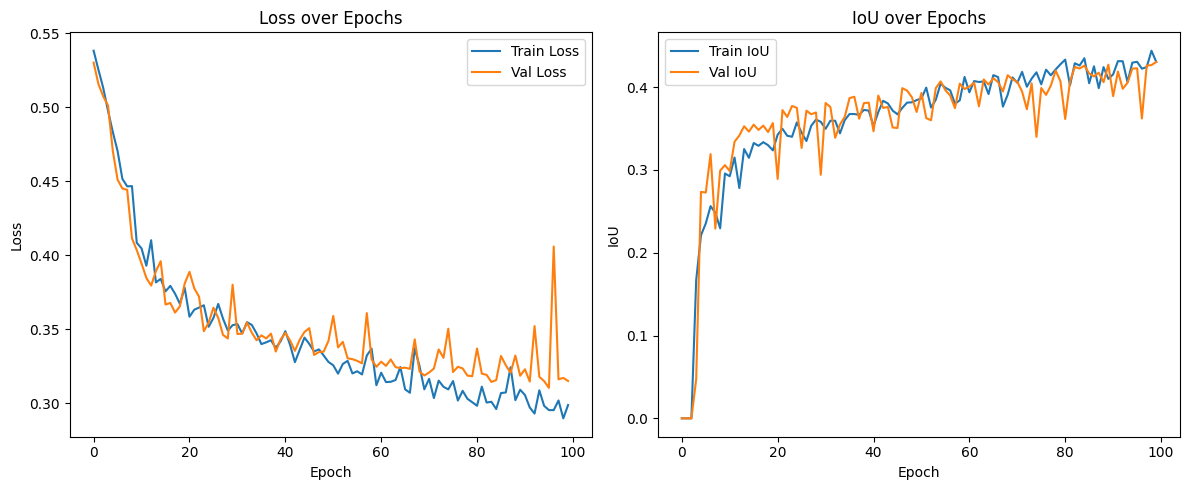

In [13]:
# --- 1. Get Dataloaders ---
dataloaders, id_splits = get_dataloaders(config)

# --- 2. Define and Select Model ---
models = {
    "ConvNeXtUNet": ConvNeXtUNet,
    "SettleNet": SettleNet,
}
# Select model here
model_name = "ConvNeXtUNet"
if model_name not in models:
    raise ValueError(f"Model '{model_name}' not recognized. Available models: {list(models.keys())}")

model = models[model_name](config)
print(f"\n--- Model Selected: {model_name} ---")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# --- 3. Run the entire experiment (training and evaluation) ---
history = run_experiment(config, model, dataloaders, model_name)

# --- 4. Plot Results ---
plot_history(history)